In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import sklearn.metrics as skm
from scipy.stats import ks_2samp
import math
import shap
from sklearn.linear_model import LogisticRegression
from scipy.stats import spearmanr
import datetime as dt

# silence warnings
import warnings
warnings.filterwarnings('ignore')

# binning
try:
    from optbinning import OptimalBinning
except:
    ! pip install optbinning
    from optbinning import OptimalBinning

(CVXPY) Jan 28 11:40:26 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Jan 28 11:40:26 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')


In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2025-01-28 23:40:26.928836


#### Functions

In [3]:
def target_by_data_set(df, str_target):
    df_tmp = df.groupby(by='data_set', as_index=False).agg({
        str_target: 'mean',
    })
    df_tmp['sort'] = df_tmp['data_set'].map(dict_sort)
    df_tmp.sort_values(by='sort', ascending=True, inplace=True)
    df_tmp.drop('sort', axis=1, inplace=True)

    # plot
    x = df_tmp['data_set']
    y = df_tmp[str_target]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by Data Set')
    ax.set_xlabel('Data Set')
    ax.set_ylabel(f'Mean {str_target}')
    # bars
    bars = ax.bar(x, y)
    # add labels to the bars
    ax.bar_label(bars, fmt='%.4f')
    # show
    plt.show()

In [4]:
def target_by_feature(df, str_col, str_target):
    df_tmp = df[df['data_set'] == 'train'].groupby(by=str_col, as_index=False).agg({
        str_target: 'mean',
    })

    # plot
    x = df_tmp[str_col].astype(str)
    y = df_tmp[str_target]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by {str_col}')
    ax.set_xlabel('Data Set')
    ax.set_ylabel(f'Mean {str_target}')
    # bars
    bars = ax.bar(x, y)
    # add labels to the bars
    ax.bar_label(bars, fmt='%.4f')
    # show
    plt.show()

In [5]:
def target_by_feature_quantile(df, str_col, int_n_quantiles, str_target):
    # get quantile
    df_tmp = df[df['data_set'] == 'train'].copy()
    # replace infs with nan
    df_tmp[str_col] = df_tmp[str_col].replace(np.inf, np.nan)
    # drop missing rows
    df_tmp = df_tmp.dropna(subset=[str_col])
    # get quantile
    df_tmp['quantile'] = pd.qcut(df_tmp[str_col], q=int_n_quantiles, duplicates='drop')
    # min-max
    df_tmp['min'] = df_tmp[str_col]
    df_tmp['max'] = df_tmp[str_col]
    # get target mean by quangtile
    df_tmp = df_tmp.groupby(by='quantile', as_index=False).agg({
        'min': 'min',
        'max': 'max',
        str_target: 'mean',
    })
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # rank
    df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'{str_target} by {str_col} Quantile')
    ax.set_xlabel(f'{str_col} Quantile')
    ax.set_ylabel(str_target)
    ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target])
    plt.show()

In [6]:
def get_suggested_constraints(df, list_cols_model, str_target, int_n_quantiles):
    list_dict_row = []
    for col in tqdm(list_cols_model):
        # df_tmp
        df_tmp = df.copy()
        # replace infs with nan
        df_tmp[col] = df_tmp[col].replace(np.inf, np.nan)
        # drop missing rows
        df_tmp = df_tmp.dropna(subset=[col])
        # get number of unique values
        int_n_unique = df_tmp[col].nunique()
        # logic
        if int_n_unique <= int_n_quantiles:
            # create a feature named quantile
            df_tmp['quantile'] = df_tmp[str_col]
        else:
            # get quantile
            df_tmp['quantile'] = pd.qcut(df_tmp[col], q=int_n_quantiles, duplicates='drop')
        # min-max
        df_tmp['min'] = df_tmp[col]
        df_tmp['max'] = df_tmp[col]
        # get target mean by quangtile
        df_tmp = df_tmp.groupby(by='quantile', as_index=False).agg({
            'min': 'min',
            'max': 'max',
            str_target: 'mean',
        })
        # sort
        df_tmp.sort_values(by='min', ascending=True, inplace=True)
        # create rank column
        df_tmp['rank'] = range(1, df_tmp.shape[0]+1)
        # fit trend line
        try:
            flt_slope, flt_intercept = np.polyfit(x=df_tmp['rank'], y=df_tmp[str_target], deg=1)
        except:
            flt_slope = 0
            flt_intercept = 0
        # logic for monotone contraints
        if flt_slope > 0:
            int_constraint = 1
            str_imputation = 'max'
        elif flt_slope < 0:
            int_constraint = -1
            str_imputation = 'min'
        else:
            int_constraint = 0
            str_imputation = 'none'
        # make a row
        dict_row = {
            'feature': col,
            'intercept': flt_intercept,
            'slope': flt_slope,
            'constraint': int_constraint,
            'imputation': str_imputation,
        }
        list_dict_row.append(dict_row)
    # make a df
    df = pd.DataFrame(list_dict_row)
    # return
    return df

In [7]:
class OverSampling:
    def __init__(self, df, str_target, flt_target_value, flt_current_value):
        self.df = df
        self.str_target = str_target
        self.flt_target_value = flt_target_value
        self.flt_current_value = flt_current_value
    # oversample zeros
    def oversample_zeros(self):
        # get n zeros
        df_zeros = self.df[self.df[str_target] == 0].copy()
        int_n_zeros_original = df_zeros.shape[0]
        # get n ones
        df_ones = self.df[self.df[str_target] == 1].copy()
        int_n_ones_original = df_ones.shape[0]
        # get total
        int_n_total_original = int_n_zeros_original + int_n_ones_original
        # solve for the new n total to reach target
        int_n_total_new = math.ceil(int_n_ones_original / flt_target_value)
        # get n additional 0s
        int_n_additional_zeros = int_n_total_new - int_n_ones_original - int_n_zeros_original
        # get sample
        df_zeros_additional = df_zeros.sample(n=int_n_additional_zeros, random_state=42)
        # concat
        df = pd.concat([df_zeros, df_ones, df_zeros_additional])
        # shuffle
        df = df.sample(frac=1.0, random_state=42)
        # return
        return df 
    # undersample ones
    def oversample_ones(self):
        # get n zeros
        df_zeros = self.df[self.df[str_target] == 0].copy()
        int_n_zeros_original = df_zeros.shape[0]
        # get n ones
        df_ones = self.df[self.df[str_target] == 1].copy()
        int_n_ones_original = df_ones.shape[0]
        # get total
        int_n_total_original = int_n_zeros_original + int_n_ones_original
        # solve for number of 1s
        int_n_additional_ones = math.ceil((int_n_ones_original - (flt_target_value * int_n_total_original)) / (flt_target_value - 1))
        # get sample
        df_ones_additional = df_ones.sample(n=int_n_additional_ones, random_state=42)
        # concat
        df = pd.concat([df_zeros, df_ones, df_ones_additional])
        # shuffle
        df = df.sample(frac=1.0, random_state=42)
        # return
        return df
    # sample
    def sample(self):
        # logic
        if self.flt_target_value < self.flt_current_value:
            df = self.oversample_zeros()
        else:
            df = self.oversample_ones()
        # return
        return df

In [8]:
def get_logistic_regression_feat_importance(df, cls_model_inference, list_cols_model=None):
    try:
        list_cols_model = list(cls_model_inference.feature_names_in_)
    except:
        pass
    df_tmp = pd.DataFrame({
        'feature': list_cols_model,
        'importance': list(cls_model_inference.coef_[0]),
    })
    # make into dictionary
    dict_coef = dict(zip(df_tmp['feature'], df_tmp['importance']))
    # subset df
    df_tmp = df[list_cols_model].copy()
    # iterate
    for key, val in dict_coef.items():
        # multiply the feature by the coefficient
        df_tmp[key] = df_tmp[key] * val
    # get the mean for each
    list_dict_row = []
    for col in list_cols_model:
        flt_mean = df_tmp[col].mean()
        dict_row = {
            'feature': col,
            'importance': flt_mean,
        }
        list_dict_row.append(dict_row)
    # make df
    df_tmp = pd.DataFrame(list_dict_row)
    # make abs value
    df_tmp['importance_abs'] = df_tmp['importance'].apply(abs)
    # sort    
    df_tmp.sort_values(by='importance_abs', ascending=False, inplace=True)
    # return
    return df_tmp

In [9]:
# ks
def get_ks_score(y_true, y_pred):
    fpr, tpr, _ = skm.roc_curve(
        y_true=y_true,
        y_score=y_pred,
    )
    ks_stat = max(tpr - fpr)
    return ks_stat

In [10]:
def evaluate(y_train, list_predictions_train, y_test, list_predictions_test, y_holdout, list_predictions_holdout):
    # get auc
    flt_auc_train = skm.roc_auc_score(
        y_true=y_train,
        y_score=list_predictions_train,
    )
    print(f'AUC Train: {flt_auc_train:0.4f}')
    flt_auc_test = skm.roc_auc_score(
        y_true=y_test,
        y_score=list_predictions_test,
    )
    print(f'AUC Test: {flt_auc_test:0.4f}')
    flt_auc_holdout = skm.roc_auc_score(
        y_true=y_holdout,
        y_score=list_predictions_holdout,
    )
    print(f'AUC Holdout: {flt_auc_holdout:0.4f}')
    print()
    # logloss
    flt_logloss_train = skm.log_loss(
        y_true=y_train,
        y_pred=list_predictions_train,
    )
    print(f'Logloss Train: {flt_logloss_train:0.4f}')
    flt_logloss_test = skm.log_loss(
        y_true=y_test,
        y_pred=list_predictions_test,
    )
    print(f'Logloss Test: {flt_logloss_test:0.4f}')
    flt_logloss_holdout = skm.log_loss(
        y_true=y_holdout,
        y_pred=list_predictions_holdout,
    )
    print(f'Logloss Holdout: {flt_logloss_holdout:0.4f}')
    print()
    # ks
    flt_ks_train = get_ks_score(
        y_true=y_train,
        y_pred=list_predictions_train,
    )
    print(f'KS Train: {flt_ks_train:0.4f}')
    flt_ks_test = get_ks_score(
        y_true=y_test,
        y_pred=list_predictions_test,
    )
    print(f'KS Test: {flt_ks_test:0.4f}')
    flt_ks_holdout = get_ks_score(
        y_true=y_holdout,
        y_pred=list_predictions_holdout,
    )
    print(f'KS Holdout: {flt_ks_holdout:0.4f}')
    return flt_auc_train, flt_auc_test

In [11]:
def get_directions_of_predictions(X, list_predictions, str_target, list_actual, list_cols, int_n_quantiles):
    # assign predictions
    X['yhat'] = list_predictions
    # assign actual
    X[str_target] = list_actual
    # iterate and plot
    for col in tqdm(list_cols):
        # get number of unique values
        int_n_unique = X[col].nunique()
        # logic
        if int_n_unique <= int_n_quantiles:
            # create a feature named quantile
            X['quantile'] = X[col]
        else:
            # get quantile
            X['quantile'] = pd.qcut(X[col], q=int_n_quantiles, duplicates='drop')
        # get target mean by quantile
        X['min'] = X[col]
        # group
        df_tmp = X.groupby(by='quantile', as_index=False).agg({
            'min': 'min',
            'yhat': 'mean',
            str_target: 'mean',
            
        })
        # sort
        df_tmp.sort_values(by='min', ascending=True, inplace=True)
        # rank
        df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
        # plot
        fig, ax = plt.subplots(figsize=(9,5))
        ax.set_title(f'Mean Predicted and Actual by {col} Quantile')
        ax.set_xlabel(f'{col} Quantile')
        ax.set_ylabel(str_target)
        # predicted
        ax.plot(df_tmp['quantile'].astype(str), df_tmp['yhat'], label='Predicted')
        # actual
        ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target], label='Actual')
        # legend
        ax.legend()
        # show
        plt.show()

In [12]:
def get_directions_of_predictions_for_scorecard(X, list_predictions, str_target, list_actual, list_cols, df_bins):
    # assign predictions
    X['yhat'] = list_predictions
    # assign actual
    X[str_target] = list_actual
    # iterate and plot
    for col in tqdm(list_cols):
        # map bin label
        df_bins_tmp = df_bins[df_bins['feature'] == col].copy()
        # create dict
        dict_map_bin = dict(zip(df_bins_tmp['bin'], df_bins_tmp['bin_label']))
        # map
        X['bin_label'] = X[col].map(dict_map_bin)
        # group
        df_tmp = X.groupby(by='bin_label', as_index=False).agg({
            'yhat': 'mean',
            str_target: 'mean',
            
        })
        # sort
        df_tmp.sort_values(by='bin_label', ascending=True, inplace=True)
        # plot
        fig, ax = plt.subplots(figsize=(9,5))
        ax.set_title(f'Mean Predicted and Actual by {col} Bin (Ascending)')
        ax.set_xlabel(f'{col} Bin')
        ax.set_ylabel(str_target)
        # predicted
        ax.plot(df_tmp['bin_label'].astype(str), df_tmp['yhat'], label='Predicted')
        # actual
        ax.plot(df_tmp['bin_label'].astype(str), df_tmp[str_target], label='Actual')
        # legend
        ax.legend()
        # show
        plt.show()

In [13]:
def get_mean_actual_by_prediction_quantile(X, list_predictions, list_actual, str_target, int_n_quantiles, str_model_type):
    # assign
    X['yhat'] = list_predictions
    X[str_target] = list_actual
    # get quantile
    X['quantile'] = pd.qcut(X['yhat'], q=int_n_quantiles, duplicates='drop')
    # get min
    X['min'] = X['yhat']
    X['predicted'] = X['yhat']
    # group
    df_tmp = X.groupby(by='quantile', as_index=False).agg({
        'min': 'min',
        'predicted': 'mean',
        str_target: 'mean',
    })
    # sort
    df_tmp.sort_values(by='min', ascending=True, inplace=True)
    # create rank
    df_tmp['quantile'] = range(1, df_tmp.shape[0]+1)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean {str_target} by {str_model_type} Prediction Quantile')
    ax.set_xlabel('Prediction Quantile')
    ax.set_ylabel(f'Mean {str_target}')
    ax.plot(df_tmp['quantile'].astype(str), df_tmp[str_target], label='Actual')
    ax.plot(df_tmp['quantile'].astype(str), df_tmp['predicted'], label='Predicted')
    # legend
    ax.legend()
    # show
    plt.show()

In [14]:
def remove_multicollinearity(X, list_cols_model, dict_map_importance, flt_threshold):
    list_dict_row = []
    a = 0
    for col1 in tqdm(list_cols_model):
        # temporary list
        list_tmp = list_cols_model[a+1:].copy()
        for col2 in list_tmp:
            # get correlation
            x = X[col1]
            y = X[col2]
            flt_r, flt_p = spearmanr(x, y)
            # row
            dict_row = {
                'col1': col1,
                'col2': col2,
                'r': flt_r,
            }
            # append
            list_dict_row.append(dict_row)
        # add 1
        a += 1
    # make df
    df_tmp = pd.DataFrame(list_dict_row)
    # make absolute value
    df_tmp['r_abs'] = df_tmp['r'].apply(abs)
    # map importance
    df_tmp['col1_importance'] = df_tmp['col1'].map(dict_map_importance)
    df_tmp['col2_importance'] = df_tmp['col2'].map(dict_map_importance)
    # flag high correlation
    df_tmp['high_correlation'] = df_tmp['r_abs'].apply(
        lambda x: 1 if x >= flt_threshold else 0,
    )
    # subset
    df_tmp = df_tmp[df_tmp['high_correlation'] == 1].copy()
    # select feature to remove
    df_tmp['remove_feature'] = df_tmp.apply(
        lambda x: x['col2'] if x['col1_importance'] > x['col2_importance']  else x['col1'],
        axis=1,
    )
    # get feats to rm
    list_cols_remove = list(df_tmp['remove_feature'])
    # rm dups
    list_cols_remove = list(dict.fromkeys(list_cols_remove))
    # return
    return df_tmp, list_cols_remove

In [15]:
def bin_features(list_cols, X_train, y_train, X_test, X_holdout, dict_monotone_constraints):
    dict_bins = {}
    list_cols_scorecard = []
    for col in tqdm(list_cols):
        # get the monotonicity
        int_monotonicity = dict_monotone_constraints[col]
        # logic
        if int_monotonicity == -1:
            str_monotonic_trend = 'descending'
        else:
            str_monotonic_trend = 'ascending'
            
        # logic
        if col == 'ENG-loan_to_value':
            prebinning_method = 'uniform'
        else:
            prebinning_method = 'cart'
        
        # init
        cls_binning = OptimalBinning(
            name=col,
            dtype='numerical',
            solver='cp',
            monotonic_trend=str_monotonic_trend,
            prebinning_method=prebinning_method,
            user_splits=None,
            user_splits_fixed=None,
        )
        # fit
        cls_binning.fit(
            X_train[col],
            y_train,
        )
        # assign
        dict_bins[col] = cls_binning
        # transform
        str_col = f'{col}_binned'
        X_train[str_col] = cls_binning.transform(
            X_train[col],
            metric='woe',
        )
        X_test[str_col] = cls_binning.transform(
            X_test[col],
            metric='woe',
        )
        X_holdout[str_col] = cls_binning.transform(
            X_holdout[col],
            metric='woe',
        )
        # append
        list_cols_scorecard.append(str_col)
    # return
    return dict_bins, list_cols_scorecard, X_train, X_test, X_holdout

In [16]:
def weight_the_coefficients(cls_model_inference, dict_weights):
    # features and coefficients
    list_feature_names_in = list(cls_model_inference.feature_names_in_)
    arr_coef = cls_model_inference.coef_[0]
    # multiply by weights and reassign
    for key, val in dict_weights.items():
        try:
            # get idx of feature
            int_idx = list_feature_names_in.index(key)
            # get the coef
            flt_coef = arr_coef[int_idx]
            # multiply by weight
            flt_coef = flt_coef * val
            # reassign
            arr_coef[int_idx] = flt_coef
        except ValueError:
            pass
    # reassign into model
    cls_model_inference.coef_[0] = arr_coef
    # return
    return cls_model_inference

In [17]:
def prep_for_partial_score(list_predictions, y_actual, flt_prop_pred=0.6):
    df_pred = pd.DataFrame({
        'pred': list_predictions,
        'actual': y_actual,
    })
    df_pred.sort_values(by='pred', ascending=True, inplace=True)
    # get rows
    int_nrows_subset = int(flt_prop_pred * len(df_pred))
    df_pred = df_pred.iloc[:int_nrows_subset].copy()
    # return
    return df_pred

#### Constants

In [18]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_target = 'Early_Pay_Delinquency_60_720_Flag'
print(f'Target: {str_target}')

str_dirname_output = './output'

# for ordering
dict_sort = {
    'train': 1,
    'valid': 2,
    'test': 3,
    'inform': 4,
    'holdout': 5,
}

# correlation threshold
flt_threshold = 0.70

# nan threshold
flt_threshold_nan = 0.80

# max rounds
int_rounds_max = 150

# weights
dict_weights = {
    'ENG-loan_to_value_binned': 1.0,
    'g106s__tu_binned': 1.0,
}

flt_prop_pred = 1.0

Project: 20241112-simple-model-test
Task: 14_60_in_720_dl_test
Subtask: 02_model
Target: Early_Pay_Delinquency_60_720_Flag


#### Output directory

In [19]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Get data dictionary for mapping descriptions

In [20]:
str_filename = 'data_dictionary.csv'
str_local_path = f'../../data_dictionary/{str_filename}'
df_tmp = pd.read_csv(str_local_path)
dict_map_descriptions = dict(zip(df_tmp['feature_name'], df_tmp['Description']))

#### Import data

In [21]:
# import
list_str_filename = [
    'train',
    'test',
    'holdout',
]
list_df = []
for str_filename in tqdm(list_str_filename):
    str_filename_tmp = f'df_{str_filename}.gzip'
    str_uri = f's3://{str_project}/{str_task}/01_data_split/{str_filename_tmp}'
    df = pd.read_parquet(
        str_uri,
    )
    # append
    list_df.append(df)
# concatenate
df = pd.concat(list_df)
# save memory
del list_df
# show
df

100%|██████████| 3/3 [00:07<00:00,  2.40s/it]


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,request_month,row,prop_row,data_set,train,test,holdout
0,5702434,2021-07-26 16:29:29.3903686,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Iowa,Franchise,Iowa,True,...,0,0,0.616667,2021-07-01,1,0.000024,train,1,0,0
1,5714239,2021-07-26 16:39:34.1121025,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Utah,Franchise,Utah,True,...,0,0,NaN,2021-07-01,2,0.000048,train,1,0,0
2,5713063,2021-07-26 16:48:39.3211104,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,True,...,0,0,NaN,2021-07-01,3,0.000072,train,1,0,0
3,5713732,2021-07-27 09:02:35.3300974,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Michigan,Independent,Michigan,False,...,0,1,0.000000,2021-07-01,4,0.000096,train,1,0,0
4,5715634,2021-07-27 09:18:12.2190097,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Arizona,Franchise,Arizona,False,...,0,1,0.000000,2021-07-01,5,0.000120,train,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41693,6453589,2022-11-30 23:45:32+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Franchise,Michigan,False,...,0,1,0.000000,2022-11-01,41694,0.999904,holdout,0,0,1
41694,6418453,2022-11-30 23:48:36+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Independent,Michigan,False,...,0,0,0.000000,2022-11-01,41695,0.999928,holdout,0,0,1
41695,6411914,2022-11-30 23:53:12+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Washington,Independent,Washington,True,...,0,0,NaN,2022-11-01,41696,0.999952,holdout,0,0,1
41696,6434554,2022-11-30 23:57:04+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Franchise,Michigan,False,...,0,0,0.137374,2022-11-01,41697,0.999976,holdout,0,0,1


#### Remove the features that belong in a set

In [22]:
list_cols_set = [
    'agg101',
    'agg102',
    'agg103',
    'agg104',
    'agg105',
    'agg106',
    'agg107',
    'agg108',
    'agg109',
    'agg110',
    'agg111',
    'agg112',
    'agg113',
    'agg114',
    'agg115',
    'agg116',
    'agg117',
    'agg118',
    'agg119',
    'agg120',
    'agg121',
    'agg122',
    'agg123',
    'agg124',
    'agg201',
    'agg202',
    'agg203',
    'agg204',
    'agg205',
    'agg206',
    'agg207',
    'agg208',
    'agg209',
    'agg210',
    'agg211',
    'agg212',
    'agg213',
    'agg214',
    'agg215',
    'agg216',
    'agg217',
    'agg218',
    'agg219',
    'agg220',
    'agg221',
    'agg222',
    'agg223',
    'agg224',
    'agg301',
    'agg302',
    'agg303',
    'agg304',
    'agg305',
    'agg306',
    'agg307',
    'agg308',
    'agg309',
    'agg310',
    'agg311',
    'agg312',
    'agg313',
    'agg314',
    'agg315',
    'agg316',
    'agg317',
    'agg318',
    'agg319',
    'agg320',
    'agg321',
    'agg322',
    'agg323',
    'agg324',
    'agg401',
    'agg402',
    'agg403',
    'agg404',
    'agg405',
    'agg406',
    'agg407',
    'agg408',
    'agg409',
    'agg410',
    'agg411',
    'agg412',
    'agg413',
    'agg414',
    'agg415',
    'agg416',
    'agg417',
    'agg418',
    'agg419',
    'agg420',
    'agg421',
    'agg422',
    'agg423',
    'agg424',
    'agg501',
    'agg502',
    'agg503',
    'agg504',
    'agg505',
    'agg506',
    'agg507',
    'agg508',
    'agg509',
    'agg510',
    'agg511',
    'agg512',
    'agg513',
    'agg514',
    'agg515',
    'agg516',
    'agg517',
    'agg518',
    'agg519',
    'agg520',
    'agg521',
    'agg522',
    'agg523',
    'agg524',
    'agg601',
    'agg602',
    'agg603',
    'agg604',
    'agg605',
    'agg606',
    'agg607',
    'agg608',
    'agg609',
    'agg610',
    'agg611',
    'agg612',
    'agg613',
    'agg614',
    'agg615',
    'agg616',
    'agg617',
    'agg618',
    'agg619',
    'agg620',
    'agg621',
    'agg622',
    'agg623',
    'agg624',
    'agg701',
    'agg702',
    'agg703',
    'agg704',
    'agg705',
    'agg706',
    'agg707',
    'agg708',
    'agg709',
    'agg710',
    'agg711',
    'agg712',
    'agg713',
    'agg714',
    'agg715',
    'agg716',
    'agg717',
    'agg718',
    'agg719',
    'agg720',
    'agg721',
    'agg722',
    'agg723',
    'agg724',
    'agg801',
    'agg802',
    'agg803',
    'agg804',
    'agg805',
    'agg806',
    'agg807',
    'agg808',
    'agg809',
    'agg810',
    'agg811',
    'agg812',
    'agg813',
    'agg814',
    'agg815',
    'agg816',
    'agg817',
    'agg818',
    'agg819',
    'agg820',
    'agg821',
    'agg822',
    'agg823',
    'agg824',
    'aggs101',
    'aggs102',
    'aggs103',
    'aggs104',
    'aggs105',
    'aggs106',
    'aggs107',
    'aggs108',
    'aggs109',
    'aggs110',
    'aggs111',
    'aggs112',
    'aggs113',
    'aggs114',
    'aggs115',
    'aggs116',
    'aggs117',
    'aggs118',
    'aggs119',
    'aggs120',
    'aggs121',
    'aggs122',
    'aggs123',
    'aggs124',
    'rets101',
    'rets102',
    'rets103',
    'rets104',
    'rets105',
    'rets106',
    'rets107',
    'rets108',
    'rets109',
    'rets110',
    'rets111',
    'rets112',
    'rets113',
    'rets114',
    'rets115',
    'rets116',
    'rets117',
    'rets118',
    'rets119',
    'rets120',
    'rets121',
    'rets122',
    'rets123',
    'rets124',
    'revs101',
    'revs102',
    'revs103',
    'revs104',
    'revs105',
    'revs106',
    'revs107',
    'revs108',
    'revs109',
    'revs110',
    'revs110',
    'revs111',
    'revs112',
    'revs113',
    'revs114',
    'revs115',
    'revs116',
    'revs117',
    'revs118',
    'revs119',
    'revs120',
    'revs121',
    'revs122',
    'revs123',
    'revs124',
]
# add suffix
list_cols_set = [f'{col}__tu' for col in list_cols_set]
print(f'There are {len(list_cols_set)} set features')
# drop
df.drop(list_cols_set, axis=1, inplace=True)
# show
df

There are 265 set features


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,request_month,row,prop_row,data_set,train,test,holdout
0,5702434,2021-07-26 16:29:29.3903686,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Iowa,Franchise,Iowa,True,...,0,0,0.616667,2021-07-01,1,0.000024,train,1,0,0
1,5714239,2021-07-26 16:39:34.1121025,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Utah,Franchise,Utah,True,...,0,0,NaN,2021-07-01,2,0.000048,train,1,0,0
2,5713063,2021-07-26 16:48:39.3211104,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,True,...,0,0,NaN,2021-07-01,3,0.000072,train,1,0,0
3,5713732,2021-07-27 09:02:35.3300974,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Michigan,Independent,Michigan,False,...,0,1,0.000000,2021-07-01,4,0.000096,train,1,0,0
4,5715634,2021-07-27 09:18:12.2190097,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Arizona,Franchise,Arizona,False,...,0,1,0.000000,2021-07-01,5,0.000120,train,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41693,6453589,2022-11-30 23:45:32+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Franchise,Michigan,False,...,0,1,0.000000,2022-11-01,41694,0.999904,holdout,0,0,1
41694,6418453,2022-11-30 23:48:36+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Independent,Michigan,False,...,0,0,0.000000,2022-11-01,41695,0.999928,holdout,0,0,1
41695,6411914,2022-11-30 23:53:12+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Washington,Independent,Washington,True,...,0,0,NaN,2022-11-01,41696,0.999952,holdout,0,0,1
41696,6434554,2022-11-30 23:57:04+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Franchise,Michigan,False,...,0,0,0.137374,2022-11-01,41697,0.999976,holdout,0,0,1


#### Identify and drop the ln features (DLv2)

In [23]:
list_cols_ln = [col for col in df.columns if '__ln' in col.lower()]
print(f'There are {len(list_cols_ln)} ln features')
# drop
df.drop(list_cols_ln, axis=1, inplace=True)
# show
df

There are 197 ln features


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,request_month,row,prop_row,data_set,train,test,holdout
0,5702434,2021-07-26 16:29:29.3903686,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Iowa,Franchise,Iowa,True,...,0,0,0.616667,2021-07-01,1,0.000024,train,1,0,0
1,5714239,2021-07-26 16:39:34.1121025,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Utah,Franchise,Utah,True,...,0,0,NaN,2021-07-01,2,0.000048,train,1,0,0
2,5713063,2021-07-26 16:48:39.3211104,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,True,...,0,0,NaN,2021-07-01,3,0.000072,train,1,0,0
3,5713732,2021-07-27 09:02:35.3300974,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Michigan,Independent,Michigan,False,...,0,1,0.000000,2021-07-01,4,0.000096,train,1,0,0
4,5715634,2021-07-27 09:18:12.2190097,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Arizona,Franchise,Arizona,False,...,0,1,0.000000,2021-07-01,5,0.000120,train,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41693,6453589,2022-11-30 23:45:32+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Franchise,Michigan,False,...,0,1,0.000000,2022-11-01,41694,0.999904,holdout,0,0,1
41694,6418453,2022-11-30 23:48:36+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Independent,Michigan,False,...,0,0,0.000000,2022-11-01,41695,0.999928,holdout,0,0,1
41695,6411914,2022-11-30 23:53:12+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Washington,Independent,Washington,True,...,0,0,NaN,2022-11-01,41696,0.999952,holdout,0,0,1
41696,6434554,2022-11-30 23:57:04+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Franchise,Michigan,False,...,0,0,0.137374,2022-11-01,41697,0.999976,holdout,0,0,1


#### Target mean by data set

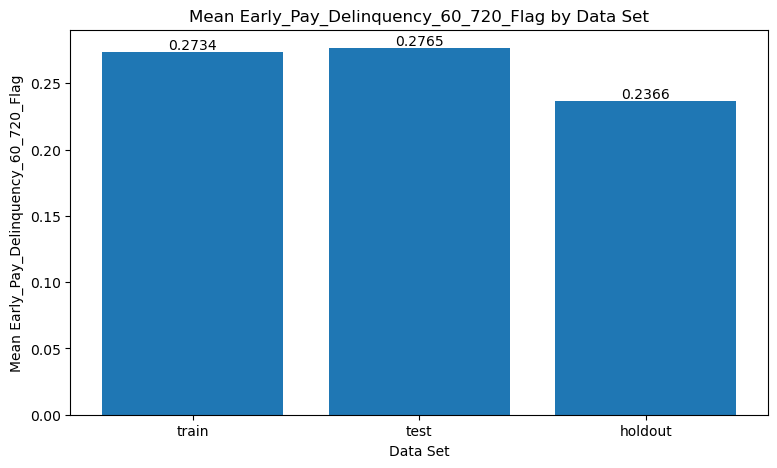

In [24]:
target_by_data_set(
    df=df,
    str_target=str_target,
)

#### Target mean by BK

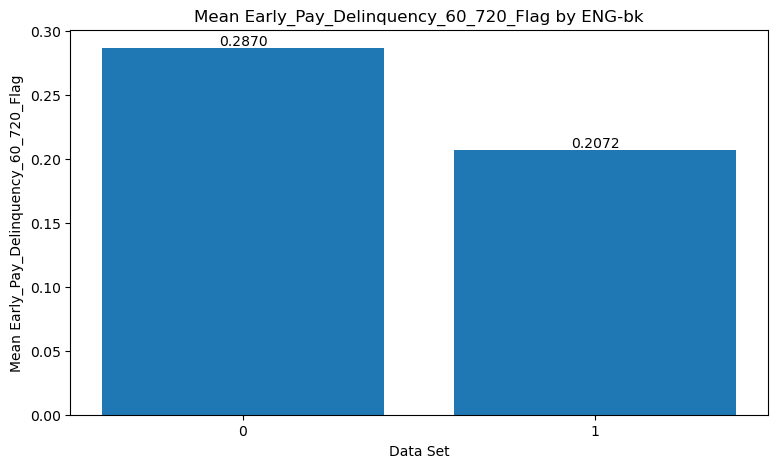

In [25]:
str_col = 'ENG-bk'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target=str_target,
)

#### Target mean by dealer type

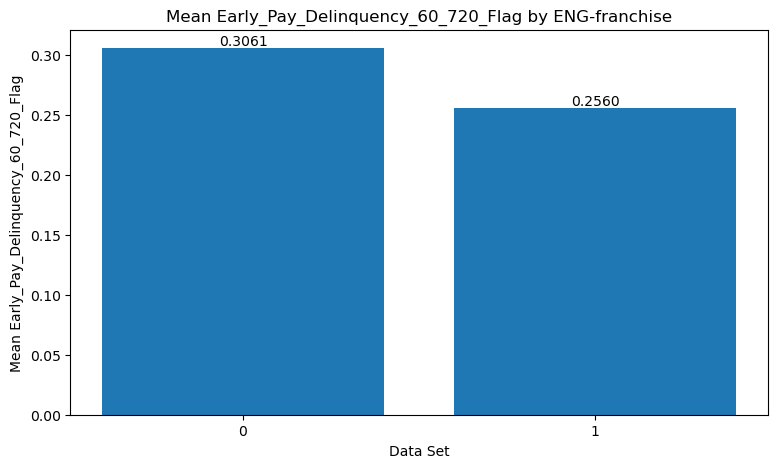

In [26]:
str_col = 'ENG-franchise'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target=str_target,
)

#### Target mean by has a codebtor

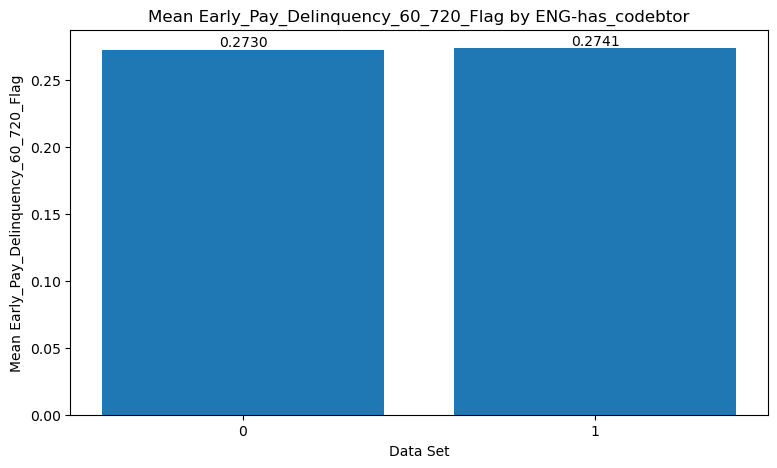

In [27]:
str_col = 'ENG-has_codebtor'
target_by_feature(
    df=df, 
    str_col=str_col,
    str_target=str_target,
)

#### Target by LTV Quantile

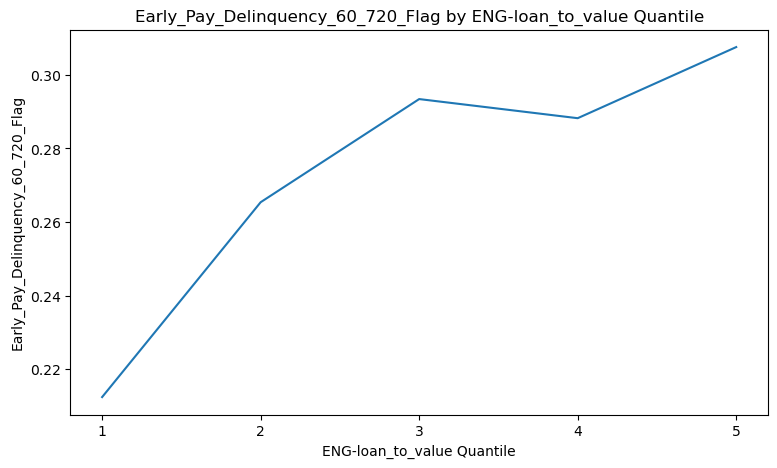

In [28]:
# get quantile
str_col = 'ENG-loan_to_value'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target=str_target,
)

#### Target by income quantile

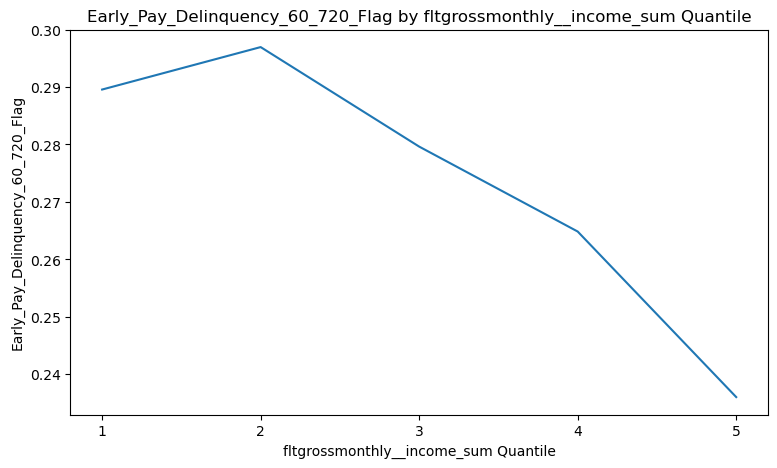

In [29]:
# get quantile
str_col = 'fltgrossmonthly__income_sum'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target=str_target,
)

#### Target by PTI Quantile

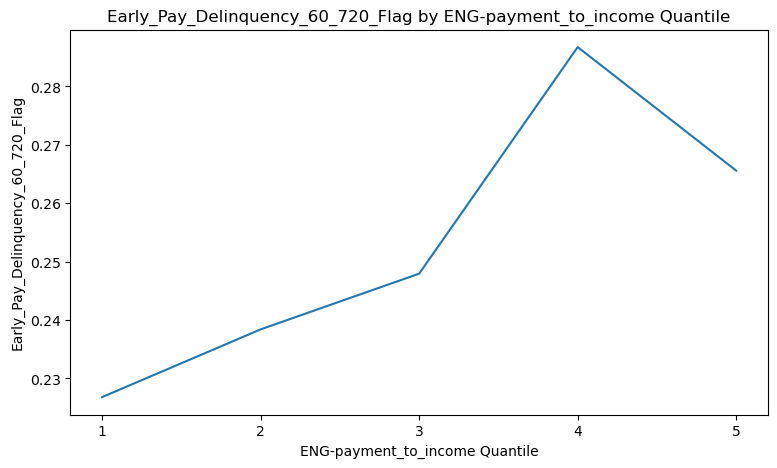

In [30]:
# get quantile
str_col = 'ENG-payment_to_income'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target=str_target,
)

#### Target by DTI quantile

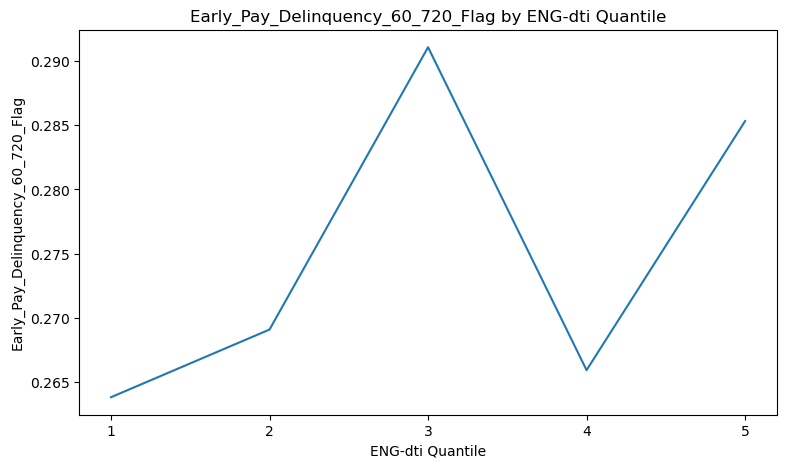

In [31]:
# get quantile
str_col = 'ENG-dti'
int_n_quantiles = 5
target_by_feature_quantile(
    df=df,
    str_col=str_col,
    int_n_quantiles=int_n_quantiles,
    str_target=str_target,
)

#### List of columns in model

In [32]:
# list cols ignore
list_cols_ignore = [
    'uniqueid__ln',
    'biglnriskviewattributesv5id__ln',
    'bigaccountid__ln',
    'bigdebtorid__ln',
    'biglnriskviewscoreid__ln',
    'bitinvalid__ln',
    'uniqueid__app',
    'bigdebtorid__app',
    'request_datetime',
    'approvaldate__app',
    'fundeddate__app',
    'defaultdate__app',
    'chargeoffdate__app',
    'applicationdate__app',
    'run_date',
    'data_set',
    'bankruptcychapter__ln',
    'bankruptcycount24month__ln',
    'bankruptcycount__ln',
    'bankruptcydismissed24month__ln',
    'bankruptcystatus__ln',
    'bankruptcytimenewest__ln',
    'criminalfelonycount12month__ln',
    'criminalfelonycount__ln',
    'addronfilecollege__ln',
    'phoneinputmobile__ln',
    'educationprogramattended__ln',
    'subjectdeceased__ln',
    'subjectage__ln',
    'dti__app',
    'flt_payment_open__tu_pmthx',
    'ssndatelowissued__ln',
    'educationevidence__ln',
    'businessassociation__ln',
    'sourcevoterregistration__ln',
    'addrcurrentcountyratio__ln',
    'addrinputcountyratio__ln',
    'addrinputtractratio__ln',
    'addrinputblockratio__ln',
    'addrcurrenttractratio__ln',
    'addrcurrentblockratio__ln',
    'ENG-franchise',
    'ENG-has_codebtor',
    'ENG-has_auto',
    'ENG-open_auto',
    'ENG-dti',
    # bks
    'ENG-bk',
    's207a__tu',
    's207s__tu',
    'cvbk__tu',
    'linkf032__tu',
    'g094s__tu',
    'g099s__tu',
    'g100s__tu',
    's207s__tu',
    's207a__tu',
    'g099a__tu',
    'cvbk__tu',
    'linkt008__tu',
    'linkt009__tu',
    'linkt010__tu',
    'linkf032__tu',
    'alert1__ln',
    'alert2__ln',
    'alert3__ln',
    'alert4__ln',
    'alert5__ln',
    'alert6__ln',
    'alert7__ln',
    'alert8__ln',
    'alert9__ln',
    'alert10__ln',
]
# structure
list_cols_structure = [
    'fltgrossmonthly__income_sum', # income
    'miles_odometer__app',
    'ENG-int_n_months',
    'ENG-int_n_months_total',
    'ENG-wtd_avg',
    'ENG-closed_auto',
    'ENG-open_and_closed_auto',
    'ENG-3mo_bad',
    'ENG-6mo_bad',
    'ENG-3mo_bad_end',
    'ENG-6mo_bad_end',
    'ENG-vehicle_age',
    'ENG-payment_to_income',
    'ENG-loan_to_value',
    'ENG-perfect_payment_hx',
    'ENG-perfect_payment_hx_open',
    'ENG-perfect_payment_hx_closed',
]
# tu
list_cols_tu = [col for col in df.columns if '__tu' in col]
# ln
list_cols_ln = [col for col in df.columns if '__ln' in col]
# combine
list_cols_model = list_cols_structure + list_cols_tu + list_cols_ln
# rm
list_cols_model = [col for col in list_cols_model if col not in list_cols_ignore]
print(f'There are {len(list_cols_model)} features available for scorecard')

There are 2178 features available for scorecard


#### Hard code list of columns in the model

In [33]:
# list_cols_model = [
#     # ability
#     'dti__app',
#     # exposure
#     'ENG-loan_to_value',
#     'miles_odometer__app',
#     # pmt hx (auto)
#     'flt_wtd_avg_open__tu_pmthx',
#     'flt_wtd_avg_closed__tu_pmthx',
#     'int_30dpd_open__tu_pmthx',
#     'int_30dpd_closed__tu_pmthx',
#     # pmt hx (overall)
#     'au206s__tu',
#     'balmag01__tu',
#     'g251b__tu',
#     'g242f__tu',
#     # length
#     'g106s__tu',
#     're01s__tu',
#     # early delinquency
#     'int_bad_3mo_open__tu_pmthx',
#     'int_bad_3mo_closed__tu_pmthx',
#     'int_bad_6mo_open__tu_pmthx',
#     'int_bad_6mo_closed__tu_pmthx',
# ]
# print(f'There are {len(list_cols_model)} features available for scorecard')

In [34]:
# rm non-numeric
list_cols_nonnumeric = []
for col in tqdm(list_cols_model):
    str_dtype = df[col].dtype
    if str_dtype not in ['int64','float64']:
        list_cols_nonnumeric.append(col)
    else:
        pass
print(f'There were {len(list_cols_nonnumeric)} non-numeric columns')
# rm
list_cols_model = [col for col in list_cols_model if col not in list_cols_nonnumeric]
print(f'There are {len(list_cols_model)} features available for scorecard')

100%|██████████| 2178/2178 [00:00<00:00, 24160.53it/s]

There were 62 non-numeric columns
There are 2116 features available for scorecard


In [35]:
# show the duplicates
ser_freq = pd.Series(list_cols_model).value_counts()
ser_freq = ser_freq[ser_freq > 1]
dict_freq = dict(ser_freq)
print('Duplicate Columns:')
a = 1
for key, val in dict_freq.items():
    print(f'{a}: {key}: {val}')
    a += 1
print('')
# rm dups
list_cols_model = list(dict.fromkeys(list_cols_model))
print(f'There are {len(list_cols_model)} features available for scorecard')

Duplicate Columns:

There are 2116 features available for scorecard


#### Get any feature with a lot of missing in any data set

In [36]:
list_isnull_all = []
for str_df in tqdm(['train','test','holdout']):
    df_tmp = df[df['data_set'] == str_df].copy()
    # get those with > 0.8
    ser_isnull = df_tmp.isnull().mean()
    list_isnull = list(ser_isnull[ser_isnull >= flt_threshold_nan].index)
    list_isnull_all += list_isnull
# rm dups
list_isnull_all = list(dict.fromkeys(list_isnull_all))
print(f'There were {len(list_isnull_all)} columns {flt_threshold_nan*100:0.2f}% or more missing in any data frame')
list_cols_model = [col for col in list_cols_model if col not in list_isnull_all]
print(f'There are {len(list_cols_model)} features available for scorecard')

100%|██████████| 3/3 [00:02<00:00,  1.31it/s]

There were 1173 columns 80.00% or more missing in any data frame
There are 982 features available for scorecard


#### Drop

In [37]:
df.drop(list_isnull_all, axis=1, inplace=True)

#### Get any feature with a lot missing in most recent month

In [38]:
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/08_prep_data/{str_filename}'
df_tmp = pd.read_parquet(str_uri)
df_tmp['request_month'] = df_tmp['request_datetime'].apply(
    lambda x: str(x)[:10],
)
df_tmp['request_month'] = pd.to_datetime(df_tmp['request_month'])
df_tmp['request_month'] = df_tmp['request_month'].dt.to_period('M').dt.to_timestamp()
dtm_max = df_tmp['request_month'].max()
df_tmp = df_tmp[df_tmp['request_month'] != dtm_max].copy()
dtm_max = df_tmp['request_month'].max()
# get prop missing by col
ser_isnull = df_tmp[list_cols_model].isnull().mean()
list_isnull_all = list(ser_isnull[ser_isnull >= flt_threshold_nan].index)
# rm dups
list_isnull_all = list(dict.fromkeys(list_isnull_all))
print(f'There were {len(list_isnull_all)} columns {flt_threshold_nan*100:0.2f}% or more missing in the most recent month of payloads')
list_cols_model = [col for col in list_cols_model if col not in list_isnull_all]
print(f'There are {len(list_cols_model)} features available for scorecard')
# save memory
del df_tmp

There were 0 columns 80.00% or more missing in the most recent month of payloads
There are 982 features available for scorecard


In [39]:
# show it
list_isnull_all

[]

#### Drop

In [40]:
df.drop(list_isnull_all, axis=1, inplace=True)

#### Get relationship with target in training data

In [41]:
df_tmp = df[df['data_set'] == 'train'].copy()
df_tmp = df_tmp.sample(frac=0.10, random_state=42)
int_n_quantiles = 5
df_tmp = get_suggested_constraints(
    df=df_tmp,
    list_cols_model=list_cols_model,
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
)
# map data dictionary
df_tmp['description'] = df_tmp['feature'].map(dict_map_descriptions)
# show
df_tmp

100%|██████████| 982/982 [00:36<00:00, 27.13it/s]


,feature,intercept,slope,constraint,imputation,description
0,fltgrossmonthly__income_sum,0.328744,-0.016313,-1,min,NaN
1,miles_odometer__app,0.187391,0.030637,1,max,NaN
2,ENG-int_n_months,0.346597,-0.026286,-1,min,NaN
3,ENG-int_n_months_total,0.359604,-0.035050,-1,min,NaN
4,ENG-wtd_avg,0.328533,-0.023669,-1,min,NaN
...,...,...,...,...,...,...
977,int_90dpd_closed__tu_pmthx,0.133162,0.133162,1,max,NaN
978,int_bad_3mo_closed__tu_pmthx,0.277911,-0.000020,-1,min,NaN
979,int_bad_6mo_closed__tu_pmthx,0.258796,0.000009,1,max,NaN
980,int_bad_3mo_closed_end__tu_pmthx,0.247380,0.000026,1,max,NaN


#### Create monotone constraints dictionary for later

In [42]:
dict_monotone_constraints = dict(zip(df_tmp['feature'], df_tmp['constraint']))

# manually adjust
dict_monotone_constraints['fltgrossmonthly__income_sum'] = -1
dict_monotone_constraints['ENG-int_n_months'] = -1
dict_monotone_constraints['ENG-int_n_months_total'] = -1
dict_monotone_constraints['int_n_months_open__tu_pmthx'] = -1
dict_monotone_constraints['int_n_months_closed__tu_pmthx'] = -1
dict_monotone_constraints['ENG-wtd_avg'] = -1
dict_monotone_constraints['ENG-bk_x_wtd_avg'] = -1
dict_monotone_constraints['ENG-has_auto'] = -1
dict_monotone_constraints['ENG-open_auto'] = -1
dict_monotone_constraints['ENG-closed_auto'] = -1
dict_monotone_constraints['ENG-open_and_closed_auto'] = -1
dict_monotone_constraints['ENG-3mo_bad'] = 1
dict_monotone_constraints['ENG-6mo_bad'] = 1
dict_monotone_constraints['ENG-3mo_bad_end'] = 1
dict_monotone_constraints['ENG-6mo_bad_end'] = 1
dict_monotone_constraints['ENG-dti'] = 1
dict_monotone_constraints['ENG-franchise'] = -1
dict_monotone_constraints['ENG-vehicle_age'] = 1
dict_monotone_constraints['miles_odometer__app'] = 1
dict_monotone_constraints['ENG-payment_to_income'] = 1
dict_monotone_constraints['ENG-loan_to_value'] = 1
dict_monotone_constraints['ENG-bk'] = -1
dict_monotone_constraints['ENG-perfect_payment_hx'] = -1
dict_monotone_constraints['ENG-perfect_payment_hx_open'] = -1
dict_monotone_constraints['ENG-perfect_payment_hx_closed'] = -1
dict_monotone_constraints['flt_wtd_avg_open__tu_pmthx'] = -1
dict_monotone_constraints['flt_wtd_avg_closed__tu_pmthx'] = -1
dict_monotone_constraints['int_bad_3mo_open__tu_pmthx'] = 1
dict_monotone_constraints['int_bad_3mo_closed__tu_pmthx'] = 1 
dict_monotone_constraints['int_bad_6mo_open__tu_pmthx'] = 1
dict_monotone_constraints['int_bad_6mo_closed__tu_pmthx'] = 1
dict_monotone_constraints['int_bad_3mo_open_end__tu_pmthx'] = 1
dict_monotone_constraints['int_bad_3mo_closed_end__tu_pmthx'] = 1 
dict_monotone_constraints['int_bad_6mo_open_end__tu_pmthx'] = 1
dict_monotone_constraints['int_bad_6mo_closed_end__tu_pmthx'] = 1

In [43]:
# save
str_filename = 'dict_monotone_constraints.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(dict_monotone_constraints, open(str_local_path, 'wb'))

# show
#dict_monotone_constraints

#### Create dictionary for imputation type

In [44]:
dict_impute_type = dict(zip(df_tmp['feature'], df_tmp['imputation']))

# manually adjust
dict_impute_type['fltgrossmonthly__income_sum'] = 'min'
dict_impute_type['ENG-int_n_months'] = 'min'
dict_impute_type['ENG-int_n_months_total'] = 'min'
dict_impute_type['int_n_months_open__tu_pmthx'] = 'min'
dict_impute_type['int_n_months_closed__tu_pmthx'] = 'min',
dict_impute_type['ENG-wtd_avg'] = 'min'
dict_impute_type['ENG-bk_x_wtd_avg'] = 'min'
dict_impute_type['ENG-has_auto'] = 'min'
dict_impute_type['ENG-open_auto'] = 'min'
dict_impute_type['ENG-closed_auto'] = 'min'
dict_impute_type['ENG-open_and_closed_auto'] = 'min'
dict_impute_type['ENG-3mo_bad'] = 'max'
dict_impute_type['ENG-6mo_bad'] = 'max'
dict_impute_type['ENG-3mo_bad_end'] = 'max'
dict_impute_type['ENG-6mo_bad_end'] = 'max'
dict_impute_type['ENG-dti'] = 'max'
dict_impute_type['ENG-franchise'] = 'min'
dict_impute_type['ENG-vehicle_age'] = 'max'
dict_impute_type['miles_odometer__app'] = 'max'
dict_impute_type['ENG-payment_to_income'] = 'max'
dict_impute_type['ENG-loan_to_value'] = 'max'
dict_impute_type['ENG-bk'] = 'min'
dict_impute_type['ENG-perfect_payment_hx'] = 'min'
dict_impute_type['ENG-perfect_payment_hx_open'] = 'min'
dict_impute_type['ENG-perfect_payment_hx_closed'] = 'min'
dict_impute_type['flt_wtd_avg_open__tu_pmthx'] = 'min'
dict_impute_type['int_bad_3mo_open__tu_pmthx'] = 'max'
dict_impute_type['int_bad_3mo_closed__tu_pmthx'] = 'max'
dict_impute_type['int_bad_6mo_open__tu_pmthx'] = 'max'
dict_impute_type['int_bad_6mo_closed__tu_pmthx'] = 'max'
dict_impute_type['int_bad_3mo_open_end__tu_pmthx'] = 'max'
dict_impute_type['int_bad_3mo_closed_end__tu_pmthx'] = 'max'
dict_impute_type['int_bad_6mo_open_end__tu_pmthx'] = 'max'
dict_impute_type['int_bad_6mo_closed_end__tu_pmthx'] = 'max'

In [45]:
# create an imputation dictionary
dict_impute = {}
df_train = df[df['data_set'] == 'train'].copy()
for key, val in tqdm(dict_impute_type.items()):
    # logic
    if val == 'min':
        flt_val = df_train[key].min()
    else:
        flt_val = df_train[key].max()
    # assign
    dict_impute[key] = flt_val

# manually impute
dict_impute['miles_odometer__app'] = df_train['miles_odometer__app'].mean()
dict_impute['ENG-loan_to_value'] = df_train['ENG-loan_to_value'].mean()

# save
str_filename = 'dict_impute.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(dict_impute, open(str_local_path, 'wb'))

# save memory
del df_train
# show
#dict_impute

100%|██████████| 988/988 [00:00<00:00, 5150.40it/s]


In [46]:
# impute
for key, val in tqdm(dict_impute.items()):
    # replace any infs with nan
    df[key] = df[key].replace(np.inf, np.nan)
    # fillna
    df[key] = df[key].fillna(val)
# show
df

100%|██████████| 988/988 [00:01<00:00, 732.94it/s]


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,request_month,row,prop_row,data_set,train,test,holdout
0,5702434,2021-07-26 16:29:29.3903686,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Iowa,Franchise,Iowa,True,...,0,0,0.616667,2021-07-01,1,0.000024,train,1,0,0
1,5714239,2021-07-26 16:39:34.1121025,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Utah,Franchise,Utah,True,...,0,0,0.000000,2021-07-01,2,0.000048,train,1,0,0
2,5713063,2021-07-26 16:48:39.3211104,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,True,...,0,0,0.000000,2021-07-01,3,0.000072,train,1,0,0
3,5713732,2021-07-27 09:02:35.3300974,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Michigan,Independent,Michigan,False,...,0,1,0.000000,2021-07-01,4,0.000096,train,1,0,0
4,5715634,2021-07-27 09:18:12.2190097,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Arizona,Franchise,Arizona,False,...,0,1,0.000000,2021-07-01,5,0.000120,train,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41693,6453589,2022-11-30 23:45:32+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Franchise,Michigan,False,...,0,1,0.000000,2022-11-01,41694,0.999904,holdout,0,0,1
41694,6418453,2022-11-30 23:48:36+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Independent,Michigan,False,...,0,0,0.000000,2022-11-01,41695,0.999928,holdout,0,0,1
41695,6411914,2022-11-30 23:53:12+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Washington,Independent,Washington,True,...,0,0,0.000000,2022-11-01,41696,0.999952,holdout,0,0,1
41696,6434554,2022-11-30 23:57:04+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Michigan,Franchise,Michigan,False,...,0,0,0.137374,2022-11-01,41697,0.999976,holdout,0,0,1


#### Show proportion missing

In [47]:
ser_isnull = df[list_cols_model].isnull().mean()
ser_isnull[ser_isnull > 0]

Series([], dtype: float64)

#### Bin features before sampling

In [48]:
df_train = df[df['data_set'] == 'train'].copy()
df_test = df[df['data_set'] == 'test'].copy()
df_holdout = df[df['data_set'] == 'holdout'].copy()
# save memory
del df

In [49]:
dict_bins, list_cols_scorecard, df_train, df_test, df_holdout = bin_features(
    list_cols=list_cols_model,
    X_train=df_train,
    y_train=df_train[str_target],
    X_test=df_test,
    X_holdout=df_holdout,
    dict_monotone_constraints=dict_monotone_constraints,
)
# pickle dict_bins
str_filename = 'dict_bins.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(dict_bins, open(str_local_path, 'wb'))

100%|██████████| 982/982 [00:38<00:00, 25.80it/s]


#### Check for no variance bins

In [50]:
# make sure every column has at least 2 bins
list_col_no_var = []
for col in tqdm(list_cols_scorecard):
    int_n_unique = df_train[col].nunique()
    # logic
    if int_n_unique < 2:
        list_col_no_var.append(col)
    else:
        pass
print(f'There are {len(list_col_no_var)} features with no variance after binning')
# rm
list_cols_scorecard = [col for col in list_cols_scorecard if col not in list_col_no_var]
print(f'There are {len(list_cols_scorecard)} features available for scorecard inclusion')

100%|██████████| 982/982 [00:00<00:00, 1659.90it/s]

There are 238 features with no variance after binning
There are 744 features available for scorecard inclusion


In [51]:
# show bins
df_tmp = df_train.copy()
df_tmp['target'] = df_train[str_target]
list_df = []
for col in tqdm(list_cols_scorecard):
    # get original column
    str_col_original = col.split('_binned')[0]
    # get min max and mean
    df_grouped = df_tmp.groupby(by=col, as_index=False).agg({
        str_col_original: ['min', 'max', 'count'],
        'target': 'mean',
    })
    # sort
    df_grouped.sort_values(by=(str_col_original, 'min'), ascending=True, inplace=True)
    df_grouped['feature'] = col
    # rename
    list_cols = ['bin','min','max','count','target','feature']
    df_grouped.columns = list_cols
    df_grouped['prop'] = df_grouped['count'] / df_grouped['count'].sum()
    # bin label
    df_grouped['bin_label'] = range(1, df_grouped.shape[0]+1)
    # reorder
    list_cols = ['feature','bin','min','max','count','prop','target','bin_label']
    df_grouped = df_grouped[list_cols].copy()
    # append
    list_df.append(df_grouped)
    
    #print(f'{a+1} - {str_col_original}')
    #print(df_grouped)
    #print()

# make df
df_bins = pd.concat(list_df)

# save
str_filename = 'df_bins.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_bins.to_csv(str_local_path, index=False)

# show
df_bins

100%|██████████| 744/744 [00:09<00:00, 78.66it/s]


,feature,bin,min,max,count,prop,target,bin_label
0,fltgrossmonthly__income_sum_binned,-0.112058,0.00,3245.72,8676,0.346790,0.296219,1
1,fltgrossmonthly__income_sum_binned,-0.088137,3245.83,3776.38,3660,0.146295,0.291257,2
2,fltgrossmonthly__income_sum_binned,0.034510,3776.64,4116.67,2048,0.081861,0.266602,3
3,fltgrossmonthly__income_sum_binned,0.042981,4116.89,4879.90,3880,0.155088,0.264948,4
4,fltgrossmonthly__income_sum_binned,0.053438,4880.18,5280.26,1529,0.061116,0.262917,5
...,...,...,...,...,...,...,...,...
0,int_bad_6mo_closed__tu_pmthx_binned,-0.083606,1.00,1.00,14880,0.594772,0.290323,2
1,int_bad_3mo_closed_end__tu_pmthx_binned,0.235304,0.00,0.00,5209,0.208210,0.229219,1
0,int_bad_3mo_closed_end__tu_pmthx_binned,-0.057739,1.00,1.00,19809,0.791790,0.285022,2
1,int_bad_6mo_closed_end__tu_pmthx_binned,0.191972,0.00,0.00,5178,0.206971,0.236964,1


In [52]:
df_bins[df_bins['feature'] == 'ENG-loan_to_value_binned']

,feature,bin,min,max,count,prop,target,bin_label
9,ENG-loan_to_value_binned,2.147141,0.185462,0.775976,95,0.003797,0.042105,1
8,ENG-loan_to_value_binned,1.034299,0.776875,0.894086,178,0.007115,0.117978,2
7,ENG-loan_to_value_binned,0.624390,0.894686,1.012695,942,0.037653,0.167728,3
6,ENG-loan_to_value_binned,0.215360,1.012821,1.130922,3089,0.123471,0.232761,4
5,ENG-loan_to_value_binned,0.041781,1.130961,1.249133,6422,0.256695,0.265182,5
4,ENG-loan_to_value_binned,-0.103403,1.249141,1.367298,7435,0.297186,0.294418,6
3,ENG-loan_to_value_binned,-0.119005,1.367374,1.603364,6823,0.272724,0.297670,7
2,ENG-loan_to_value_binned,-0.417809,1.603826,1.707916,22,0.000879,0.363636,8
1,ENG-loan_to_value_binned,-1.265106,1.744855,2.148742,7,0.000280,0.571429,9
0,ENG-loan_to_value_binned,-1.382889,2.388451,2.549193,5,0.000200,0.600000,10


#### Get simple logistic regression performance for multicollinearity

In [53]:
list_dict_row = []
for col in tqdm(list_cols_scorecard):
    # init
    cls_model_inference = LogisticRegression(
        random_state=42,
        fit_intercept=True,
    )
    # fit
    cls_model_inference.fit(
        df_train[[col]],
        df_train[str_target],
    )
    # do not adjust weights in this step!
    # get predictions
    list_predictions_test = list(cls_model_inference.predict_proba(df_test[[col]])[:,1])
    # get score
    flt_score = skm.roc_auc_score(
        y_true=df_test[str_target],
        y_score=list_predictions_test,
    )
    # row
    dict_row = {
        'feature': col,
        'score': flt_score,
    }
    # append
    list_dict_row.append(dict_row)
# df
df_tmp = pd.DataFrame(list_dict_row)
df_tmp.sort_values(by='score', ascending=False, inplace=True)
df_tmp['feature'] = df_tmp['feature'].apply(
    lambda x: x.split('_binned')[0],
)
# map importance
dict_map_importance = dict(zip(df_tmp['feature'], df_tmp['score']))
# show
df_tmp

100%|██████████| 744/744 [00:29<00:00, 25.14it/s]


,feature,score
379,g415s__tu,0.562784
422,cv15__tu,0.562784
215,g232s__tu,0.561354
219,g238s__tu,0.552977
421,cv14__tu,0.549330
...,...,...
645,linkf086__tu,0.488514
679,linkf161__tu,0.487298
667,linkf143__tu,0.486619
685,linkf170__tu,0.484199


#### Check for multicollinearity before sampling

In [54]:
# list_cols = [f'{col.split("_binned")[0]}' for col in list_cols_scorecard]
# # find multicollinear columns
# df_tmp = df_train.sample(frac=0.01, random_state=42)
# df_tmp, list_cols_remove = remove_multicollinearity(
#     X=df_tmp, 
#     list_cols_model=list_cols, 
#     dict_map_importance=dict_map_importance, 
#     flt_threshold=flt_threshold,
# )

# save
str_filename = 'df_multicollinearity.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
#df_tmp.to_csv(str_local_path, index=False)

# import
df_tmp = pd.read_csv(str_local_path)

# save
str_filename = 'list_cols_remove.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
#pickle.dump(list_cols_remove, open(str_local_path, 'wb'))

# import
list_cols_remove = pickle.load(open(str_local_path, 'rb'))

# add binned suffix
list_cols_remove = [f'{col}_binned' for col in list_cols_remove]
print('Columns to Remove:')
for a, col in enumerate(list_cols_remove):
    print(f'{a+1} - {col}')
print()

# show
df_tmp

Columns to Remove:
1 - ENG-int_n_months_total_binned
2 - ENG-3mo_bad_binned
3 - au06s__tu_binned
4 - au09s__tu_binned
5 - ENG-int_n_months_binned
6 - au21s__tu_binned
7 - ENG-closed_auto_binned
8 - au01s__tu_binned
9 - int_bad_3mo_closed__tu_pmthx_binned
10 - ENG-6mo_bad_binned
11 - ENG-perfect_payment_hx_binned
12 - au36s__tu_binned
13 - au201s__tu_binned
14 - au202s__tu_binned
15 - au203s__tu_binned
16 - flt_mean_months_to_first_bad__tu_pmthx_binned
17 - ENG-wtd_avg_binned
18 - ENG-open_and_closed_auto_binned
19 - ENG-6mo_bad_end_binned
20 - ENG-perfect_payment_hx_closed_binned
21 - ENG-3mo_bad_end_binned
22 - int_bad_6mo_open_end__tu_pmthx_binned
23 - int_bad_6mo_closed_end__tu_pmthx_binned
24 - au03s__tu_binned
25 - au12s__tu_binned
26 - au28s__tu_binned
27 - au32s__tu_binned
28 - ENG-payment_to_income_binned
29 - au35s__tu_binned
30 - au57s__tu_binned
31 - fi28s__tu_binned
32 - fi33s__tu_binned
33 - aut202__tu_binned
34 - aut203__tu_binned
35 - aut204__tu_binned
36 - aut222__tu_bi

,col1,col2,r,r_abs,col1_importance,col2_importance,high_correlation,remove_feature
0,ENG-int_n_months,ENG-int_n_months_total,0.928763,0.928763,0.536567,0.535469,1,ENG-int_n_months_total
1,ENG-int_n_months,ENG-3mo_bad,-0.812483,0.812483,0.536567,0.507772,1,ENG-3mo_bad
2,ENG-int_n_months,au06s__tu,-0.771509,0.771509,0.536567,0.508226,1,au06s__tu
3,ENG-int_n_months,au09s__tu,-0.797946,0.797946,0.536567,0.523945,1,au09s__tu
4,ENG-int_n_months,au20s__tu,0.712262,0.712262,0.536567,0.543295,1,ENG-int_n_months
...,...,...,...,...,...,...,...,...
9705,int_60dpd_closed__tu_pmthx,int_bad_6mo_closed__tu_pmthx,0.736107,0.736107,0.511962,0.518697,1,int_60dpd_closed__tu_pmthx
9706,int_90dpd_closed__tu_pmthx,int_bad_3mo_closed__tu_pmthx,0.875578,0.875578,0.508039,0.508473,1,int_90dpd_closed__tu_pmthx
9707,int_90dpd_closed__tu_pmthx,int_bad_6mo_closed__tu_pmthx,0.744399,0.744399,0.508039,0.518697,1,int_90dpd_closed__tu_pmthx
9708,int_bad_3mo_closed__tu_pmthx,int_bad_6mo_closed__tu_pmthx,0.826401,0.826401,0.508473,0.518697,1,int_bad_3mo_closed__tu_pmthx


In [55]:
'ENG-loan_to_value' in list_cols_remove

False

In [56]:
'g106s__tu' in list_cols_remove

False

#### Get info from inform set

In [57]:
# # get target value
# flt_target_value = df_holdout[str_target].mean()
# print(f'Target Value: {flt_target_value:0.4f}')

#### Get train to match the inform set

In [58]:
# %%time

# # get current target mean
# flt_current_value = df_train[str_target].mean()
# print(f'Target Value Before Sampling: {flt_current_value:0.4f}')
# # init
# cls_sample = OverSampling(
#     df=df_train,
#     str_target=str_target,
#     flt_target_value=flt_target_value,
#     flt_current_value=flt_current_value,
# )
# # sample
# df_train = cls_sample.sample()
# # get current target mean
# flt_current_value = df_train[str_target].mean()
# print(f'Target Value After Sampling: {flt_current_value:0.4f}')
# print()
# # show
# df_train

#### Get test to match the inform set


In [59]:
# %%time

# # get current target mean
# flt_current_value = df_test[str_target].mean()
# print(f'Target Value Before Sampling: {flt_current_value:0.4f}')
# # init
# cls_sample = OverSampling(
#     df=df_test,
#     str_target=str_target,
#     flt_target_value=flt_target_value,
#     flt_current_value=flt_current_value,
# )
# # sample
# df_test = cls_sample.sample()
# # get current target mean
# flt_current_value = df_test[str_target].mean()
# print(f'Target Value After Sampling: {flt_current_value:0.4f}')
# print()
# # show
# df_test

#### List of columns to start

In [60]:
print(f'Starting with {len(list_cols_scorecard)} features:')

Starting with 744 features:


#### Get the scorecard cols and the original col

In [61]:
list_cols_original = []
for col in tqdm(list_cols_scorecard):
    str_col_original = col.split('_binned')[0]
    # append
    list_cols_original.append(str_col_original)
# combine
list_cols_x = list_cols_original + list_cols_scorecard

100%|██████████| 744/744 [00:00<00:00, 1063223.91it/s]


#### Split into X and y

In [62]:
# train
X_train = df_train[list_cols_x].copy()
y_train = df_train[str_target]
# save memory
del df_train

In [63]:
X_train.shape

(25018, 1488)

In [64]:
# test
X_test = df_test[list_cols_x].copy()
y_test = df_test[str_target]
# save memory
del df_test

In [65]:
X_test.shape

(8340, 1488)

In [66]:
# holdout
X_holdout = df_holdout[list_cols_x].copy()
y_holdout = df_holdout[str_target]
# save memory
del df_holdout

In [67]:
X_holdout.shape

(8340, 1488)

#### Baseline model

There are 102 features available for scorecard inclusion


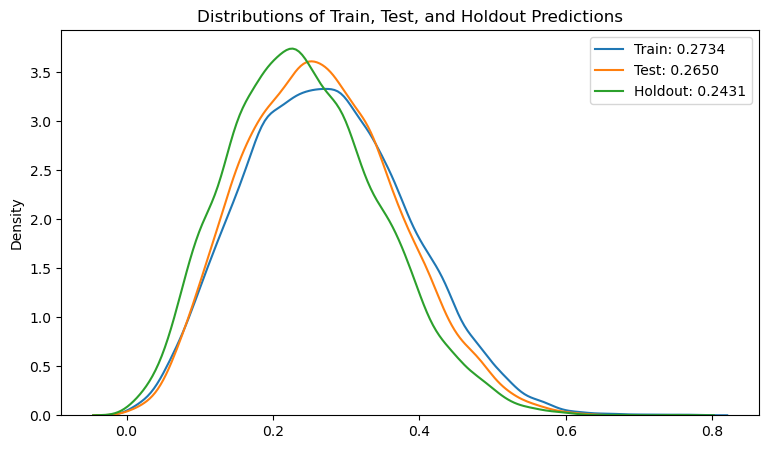

In [68]:
# rm collinear
list_cols_scorecard = [col for col in list_cols_scorecard if col not in list_cols_remove]
print(f'There are {len(list_cols_scorecard)} features available for scorecard inclusion')

# init
cls_model_inference = LogisticRegression(
    random_state=42,
    fit_intercept=True,
)
# fit
cls_model_inference.fit(
    X_train[list_cols_scorecard],
    y_train,
)
# adjust weights
cls_model_inference = weight_the_coefficients(
    cls_model_inference=cls_model_inference,
    dict_weights=dict_weights,
)

# get predictions
list_predictions_train = list(cls_model_inference.predict_proba(X_train[list_cols_scorecard])[:,1])
list_predictions_test = list(cls_model_inference.predict_proba(X_test[list_cols_scorecard])[:,1])
list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout[list_cols_scorecard])[:,1])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Train, Test, and Holdout Predictions')
sns.kdeplot(list_predictions_train, label=f'Train: {np.mean(list_predictions_train):0.4f}')
sns.kdeplot(list_predictions_test, label=f'Test: {np.mean(list_predictions_test):0.4f}')
sns.kdeplot(list_predictions_holdout, label=f'Holdout: {np.mean(list_predictions_holdout):0.4f}')
# legend
ax.legend()
# show
plt.show()

In [69]:
# eval
flt_auc_train, flt_auc_test = evaluate(
    y_train=y_train,
    list_predictions_train=list_predictions_train,
    y_test=y_test,
    list_predictions_test=list_predictions_test,
    y_holdout=y_holdout,
    list_predictions_holdout=list_predictions_holdout,
)

AUC Train: 0.6601
AUC Test: 0.6440
AUC Holdout: 0.6406

Logloss Train: 0.5536
Logloss Test: 0.5630
Logloss Holdout: 0.5243

KS Train: 0.2279
KS Test: 0.2121
KS Holdout: 0.2166


#### Forward stepwise

In [70]:
# map description
dict_map_descriptions_bin = {f'{key}_binned': val for key, val in dict_map_descriptions.items()}

# make copy
list_cols_start = list_cols_scorecard.copy()

flt_target_train = 0.5
flt_target_test = 0.5
list_cols_in_model = [
    'ENG-loan_to_value_binned',
    'fltgrossmonthly__income_sum_binned',
    'miles_odometer__app_binned',
    'flt_wtd_avg_open__tu_pmthx_binned',
    'flt_wtd_avg_closed__tu_pmthx_binned',
]
list_dict_row_a = []
counter = 0
while True:
    list_dict_row_b = []
    # make sure the features have been removed
    list_cols_start = [col for col in list_cols_start if col not in list_cols_in_model]
    # iterate through cols
    for col_a in tqdm(list_cols_start):
        # add to 
        list_cols_scorecard_tmp = list_cols_in_model + [col_a]
        
        # fit model
        cls_model_inference = LogisticRegression(
            random_state=42,
            fit_intercept=True,
        )
        cls_model_inference.fit(
            X_train[list_cols_scorecard_tmp].copy(),
            y_train,
        )
        # adjust weights
        cls_model_inference = weight_the_coefficients(
            cls_model_inference=cls_model_inference,
            dict_weights=dict_weights,
        )
        # get score - train
        list_predictions_tmp = list(cls_model_inference.predict_proba(X_train[list_cols_scorecard_tmp])[:,1])     
        # get score
        flt_score_train = skm.roc_auc_score(
            y_true=y_train,
            y_score=list_predictions_tmp,
        )
        # get score - test
        list_predictions_tmp = list(cls_model_inference.predict_proba(X_test[list_cols_scorecard_tmp])[:,1])       
        # get score
        flt_score_test = skm.roc_auc_score(
            y_true=y_test,
            y_score=list_predictions_tmp,
        )
        # make row
        dict_row_b = {
            'feature': col_a,
            'score_train': flt_score_train,
            'score_test': flt_score_test,
        }
        # append
        list_dict_row_b.append(dict_row_b)
    
    # make df
    df_tmp = pd.DataFrame(list_dict_row_b)
    
    # get diffs
    df_tmp['diff_train'] = df_tmp['score_train'] - flt_target_train
    df_tmp['diff_test'] = df_tmp['score_test'] - flt_target_test
    
    # subset to where both are positive
    df_tmp = df_tmp[(df_tmp['diff_train'] > 0) & (df_tmp['diff_test'] >= 0)].copy()
    
    # get number of rows
    int_nrows = df_tmp.shape[0]
    
    # logic to break loop
    if int_nrows == 0:
        break
    else:
        pass
    
    # get the wtd avg
    df_tmp['diff_overall'] = df_tmp.apply(
        lambda x: np.average(
            [x['diff_train'], x['diff_test']],
            weights=[1,1],
        ),
        axis=1,
    )
    
    # sort
    df_tmp.sort_values(by='diff_overall', ascending=False, inplace=True)
    
    # get best scores
    flt_score_train = df_tmp['score_train'].iloc[0]
    flt_score_test = df_tmp['score_test'].iloc[0]
    
    # get targets
    flt_target_train = flt_score_train
    flt_target_test = flt_score_test
    
    # get the feature that improves performance most upon addition
    str_feat_add = df_tmp['feature'].iloc[0]
    # append
    list_cols_in_model.append(str_feat_add)
    
    # get the description
    try:
        str_description = dict_map_descriptions_bin[str_feat_add]
    except KeyError:
        str_description = ''
    
    # make row
    dict_row_a = {
        'list_cols_in_model': list_cols_in_model.copy(),
        'n_feats': len(list_cols_in_model.copy()),
        'feature': str_feat_add,
        'target_train': flt_target_train,
        'target_test': flt_target_test,
        'score_train': flt_score_train,
        'score_test': flt_score_test,
        'description': str_description,
    }
    # append
    list_dict_row_a.append(dict_row_a)

    # make df
    df_stepwise = pd.DataFrame(list_dict_row_a)
    # save
    str_filename = 'df_stepwise.csv'
    str_local_path = f'{str_dirname_output}/{str_filename}'
    df_stepwise.to_csv(str_local_path, index=False)
    
    # add to counter
    counter += 1
    
    if counter == int_rounds_max:
        break
    else:
        pass

# get features
list_cols_scorecard_stepwise = df_stepwise['list_cols_in_model'].iloc[-1]
print(f'There are {len(list_cols_scorecard_stepwise)} features that do not drift inappropriately')

# show
df_stepwise

100%|██████████| 51/51 [00:06<00:00,  8.35it/s]

There are 52 features that do not drift inappropriately


,list_cols_in_model,n_feats,feature,target_train,target_test,score_train,score_test,description
0,"[ENG-loan_to_value_binned, fltgrossmonthly__in...",6,cv15__tu_binned,0.599066,0.592706,0.599066,0.592706,Number of deduped auto inquiries
1,"[ENG-loan_to_value_binned, fltgrossmonthly__in...",7,linkt001__tu_binned,0.607092,0.600951,0.607092,0.600951,Number of non-military addresses in last 7 years
2,"[ENG-loan_to_value_binned, fltgrossmonthly__in...",8,br109s__tu_binned,0.614691,0.609756,0.614691,0.609756,Number of bank revolving trades with past due ...
3,"[ENG-loan_to_value_binned, fltgrossmonthly__in...",9,in21s__tu_binned,0.619715,0.615414,0.619715,0.615414,Months since most recent installment trade opened
4,"[ENG-loan_to_value_binned, fltgrossmonthly__in...",10,balmag01__tu_binned,0.625531,0.621207,0.625531,0.621207,Non-mortgage balance magnitude algorithm over ...
5,"[ENG-loan_to_value_binned, fltgrossmonthly__in...",11,rev326__tu_binned,0.628975,0.625770,0.628975,0.625770,Average Total Open-to-Buy for Revolving accoun...
6,"[ENG-loan_to_value_binned, fltgrossmonthly__in...",12,g310s__tu_binned,0.634681,0.629339,0.634681,0.629339,Worst rating on all trades in past 12 months
7,"[ENG-loan_to_value_binned, fltgrossmonthly__in...",13,g232s__tu_binned,0.637311,0.634309,0.637311,0.634309,Number of inquiries (includes duplicates)
8,"[ENG-loan_to_value_binned, fltgrossmonthly__in...",14,rp01s__tu_binned,0.639610,0.635719,0.639610,0.635719,Number of repossession trades
9,"[ENG-loan_to_value_binned, fltgrossmonthly__in...",15,jt20s__tu_binned,0.641540,0.638040,0.641540,0.638040,Months since oldest joint trade opened


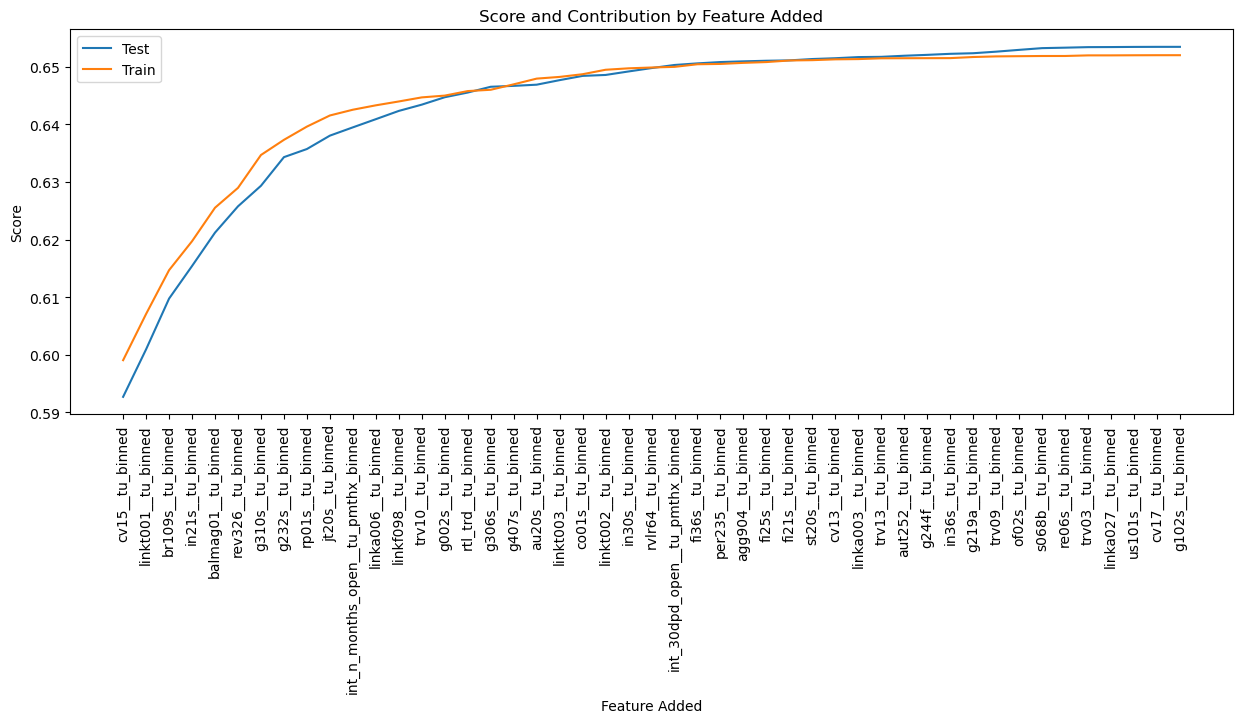

In [71]:
# plot
x = df_stepwise['feature']
y = df_stepwise['score_test']
z = df_stepwise['score_train']
fig, ax = plt.subplots(figsize=(15,5))
ax.set_title('Score and Contribution by Feature Added')
ax.set_xlabel('Feature Added')
ax.set_ylabel('Score')
ax.plot(x, y, label='Test')
ax.plot(x, z, label='Train')
ax.set_xticklabels(x, rotation=90)
ax.legend()

# save
str_filename = 'plt_forward_stepwise.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

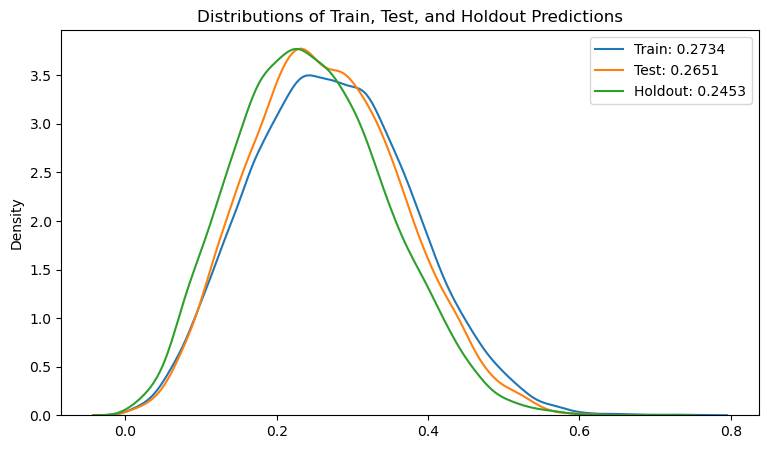

In [72]:
# init
cls_model_inference = LogisticRegression(
    random_state=42,
    fit_intercept=True,
)
# fit
cls_model_inference.fit(
    X_train[list_cols_scorecard_stepwise].copy(),
    y_train,
)
# adjust weights
cls_model_inference = weight_the_coefficients(
    cls_model_inference=cls_model_inference,
    dict_weights=dict_weights,
)

# get predictions
list_predictions_train = list(cls_model_inference.predict_proba(X_train[list_cols_scorecard_stepwise])[:,1])
list_predictions_test = list(cls_model_inference.predict_proba(X_test[list_cols_scorecard_stepwise])[:,1])
list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout[list_cols_scorecard_stepwise])[:,1])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Train, Test, and Holdout Predictions')
sns.kdeplot(list_predictions_train, label=f'Train: {np.mean(list_predictions_train):0.4f}')
sns.kdeplot(list_predictions_test, label=f'Test: {np.mean(list_predictions_test):0.4f}')
sns.kdeplot(list_predictions_holdout, label=f'Holdout: {np.mean(list_predictions_holdout):0.4f}')
# legend
ax.legend()
# show
plt.show()

In [73]:
# eval
flt_auc_train, flt_auc_test = evaluate(
    y_train=y_train,
    list_predictions_train=list_predictions_train,
    y_test=y_test,
    list_predictions_test=list_predictions_test,
    y_holdout=y_holdout,
    list_predictions_holdout=list_predictions_holdout,
)

AUC Train: 0.6520
AUC Test: 0.6535
AUC Holdout: 0.6356

Logloss Train: 0.5568
Logloss Test: 0.5598
Logloss Holdout: 0.5256

KS Train: 0.2166
KS Test: 0.2278
KS Holdout: 0.2075


#### Force features

In [74]:
list_feats_force = [
    #'ENG-loan_to_value',
]
list_feats_force = [f'{col}_binned' for col in list_feats_force]
# combine
list_cols_scorecard = list_cols_scorecard_stepwise + list_feats_force
# rm dups
list_cols_scorecard = list(dict.fromkeys(list_cols_scorecard))
# print
print(f'There are {len(list_cols_scorecard)} features in the scorecard')

There are 52 features in the scorecard


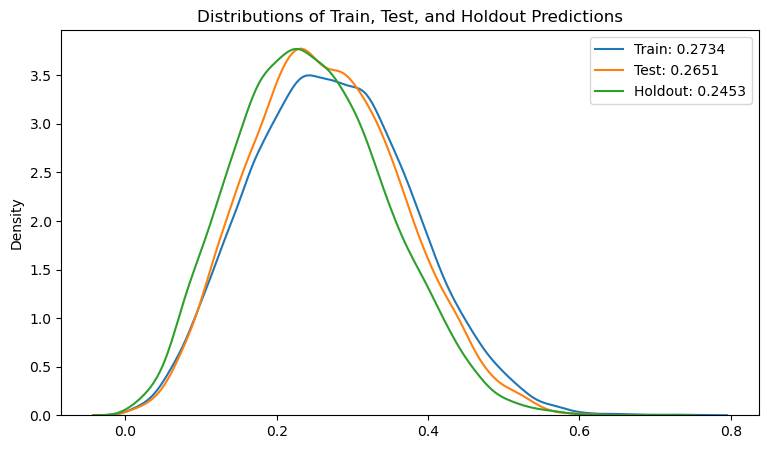

In [75]:
# init
cls_model_inference = LogisticRegression(
    random_state=42,
    fit_intercept=True,
)
# fit
cls_model_inference.fit(
    X_train[list_cols_scorecard].copy(),
    y_train,
)
# adjust weights
cls_model_inference = weight_the_coefficients(
    cls_model_inference=cls_model_inference,
    dict_weights=dict_weights,
)

# get predictions
list_predictions_train = list(cls_model_inference.predict_proba(X_train[list_cols_scorecard])[:,1])
list_predictions_test = list(cls_model_inference.predict_proba(X_test[list_cols_scorecard])[:,1])
list_predictions_holdout = list(cls_model_inference.predict_proba(X_holdout[list_cols_scorecard])[:,1])

# plot distributions
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Train, Test, and Holdout Predictions')
sns.kdeplot(list_predictions_train, label=f'Train: {np.mean(list_predictions_train):0.4f}')
sns.kdeplot(list_predictions_test, label=f'Test: {np.mean(list_predictions_test):0.4f}')
sns.kdeplot(list_predictions_holdout, label=f'Holdout: {np.mean(list_predictions_holdout):0.4f}')
# legend
ax.legend()
# show
plt.show()

In [76]:
# eval
flt_auc_train, flt_auc_test = evaluate(
    y_train=y_train,
    list_predictions_train=list_predictions_train,
    y_test=y_test,
    list_predictions_test=list_predictions_test,
    y_holdout=y_holdout,
    list_predictions_holdout=list_predictions_holdout,
)

AUC Train: 0.6520
AUC Test: 0.6535
AUC Holdout: 0.6356

Logloss Train: 0.5568
Logloss Test: 0.5598
Logloss Holdout: 0.5256

KS Train: 0.2166
KS Test: 0.2278
KS Holdout: 0.2075


#### Get intercept

In [77]:
# get intercept
flt_intercept = cls_model_inference.intercept_[0]
print(f'Intercept: {flt_intercept}')

Intercept: -0.9792527372901825


In [78]:
# get feature importance
dict_map_descriptions_bin = {f'{key}_binned': val for key, val in dict_map_descriptions.items()}
df_tmp = get_logistic_regression_feat_importance(
    cls_model_inference=cls_model_inference,
    list_cols_model=list_cols_scorecard,
    df=X_test,
)
# map desceription
df_tmp['description'] = df_tmp['feature'].map(dict_map_descriptions_bin)

# save
str_filename = 'df_feat_imp.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_csv(str_local_path, index=False)

# show
df_tmp

,feature,importance,importance_abs,description
10,rev326__tu_binned,-0.015389,0.015389,Average Total Open-to-Buy for Revolving accoun...
23,au20s__tu_binned,-0.013869,0.013869,Months since oldest auto trade opened
6,linkt001__tu_binned,-0.012772,0.012772,Number of non-military addresses in last 7 years
11,g310s__tu_binned,-0.011848,0.011848,Worst rating on all trades in past 12 months
2,miles_odometer__app_binned,0.011318,0.011318,NaN
9,balmag01__tu_binned,-0.011225,0.011225,Non-mortgage balance magnitude algorithm over ...
1,fltgrossmonthly__income_sum_binned,-0.010642,0.010642,NaN
7,br109s__tu_binned,-0.010270,0.010270,Number of bank revolving trades with past due ...
15,int_n_months_open__tu_pmthx_binned,-0.008547,0.008547,NaN
20,rtl_trd__tu_binned,-0.008445,0.008445,Number of retail trades


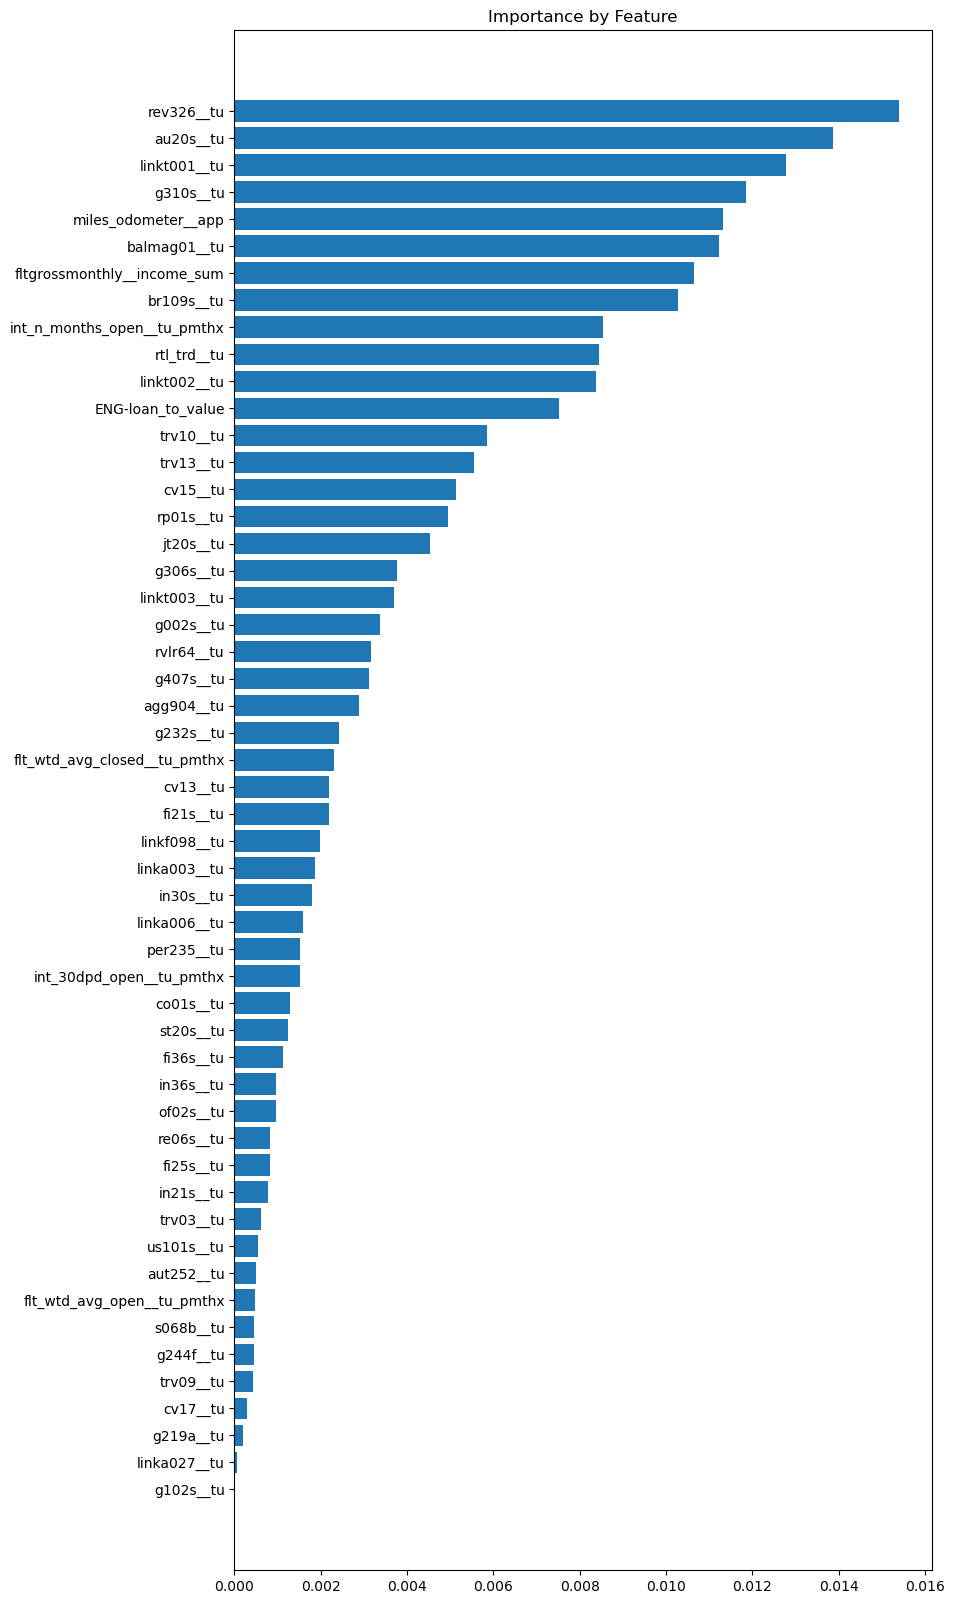

In [79]:
# plot
df_tmp.sort_values(by='importance_abs', ascending=True, inplace=True)
df_tmp['feature_tmp'] = df_tmp['feature'].apply(
    lambda x: x.split('_binned')[0],
)
x = df_tmp['feature_tmp']
y = df_tmp['importance_abs']
fig, ax = plt.subplots(figsize=(9,20))
ax.set_title('Importance by Feature')
ax.barh(x, y)
# show
plt.show()

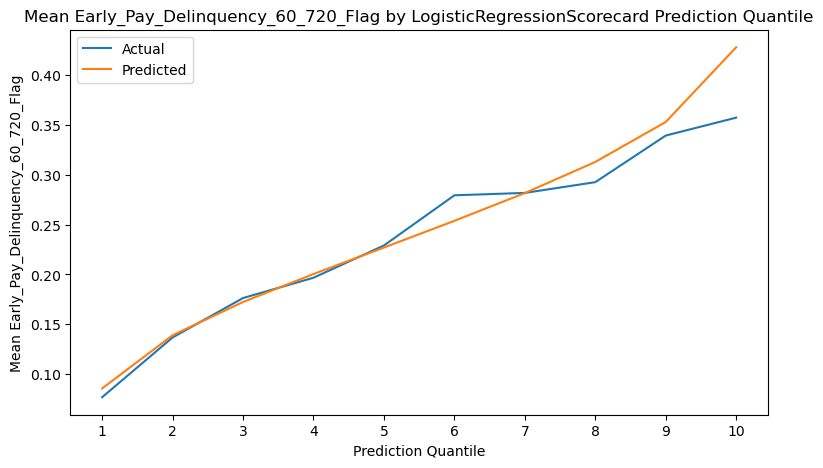

In [80]:
# mean actual by prediction quantile in holdout
int_n_quantiles = 10
get_mean_actual_by_prediction_quantile(
    X=X_holdout.copy(),
    list_predictions=list_predictions_holdout,
    list_actual=list(y_holdout),
    str_target=str_target,
    int_n_quantiles=int_n_quantiles,
    str_model_type='LogisticRegressionScorecard',
)

In [81]:
# # directions of predictions in test
# int_n_quantiles = 10
# get_directions_of_predictions_for_scorecard(
#     X=X_test.copy(),
#     list_predictions=list_predictions_test,
#     str_target=str_target,
#     list_actual=list(y_test),
#     list_cols=list_cols_scorecard,
#     df_bins=df_bins,
# )